In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler, RobustScaler

# Set plot style for better visuals
sns.set_theme(style="whitegrid")
%matplotlib inline


# 1. Dynamically locate the project root directory
NOTEBOOK_DIR = Path(os.getcwd())
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_PATH = DATA_DIR / "creditcard.csv"

# 2. Check if the file exists before reading to avoid generic errors
if not RAW_DATA_PATH.exists():
    raise FileNotFoundError(
        f"❌ Could not find the dataset at: {RAW_DATA_PATH.resolve()}\n"
        f"Please run your ingestion/download code cell first!"
    )

# 3. Read the data into a Pandas DataFrame
print(f"📖 Loading data from: {RAW_DATA_PATH.name}...")
df = pd.read_csv(RAW_DATA_PATH)

# 4. Inspect the shape and first few rows
print(f"📊 Dataset successfully loaded! Shape: {df.shape[0]:,} rows, {df.shape[1]} columns.\n")
df.head()


📖 Loading data from: creditcard.csv...
📊 Dataset successfully loaded! Shape: 284,807 rows, 31 columns.



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(f"Dataset Shape: {df.shape}")
df.info()

Dataset Shape: (284807, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-n

Domain Note: Features $V_1, V_2, \dots, V_{28}$ are numerical input variables obtained with a PCA (Principal Component Analysis) transformation due to confidentiality issues. The only features which have not been transformed with PCA are 'Time' and 'Amount'.

In [5]:
# Count the occurrences of each class
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100

print("Class Distribution:")
print(pd.DataFrame({'Counts': class_counts, 'Percentage (%)': class_percentages}))

Class Distribution:
       Counts  Percentage (%)
Class                        
0      284315       99.827251
1         492        0.172749


/tmp/ipykernel_43587/68479531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set1')


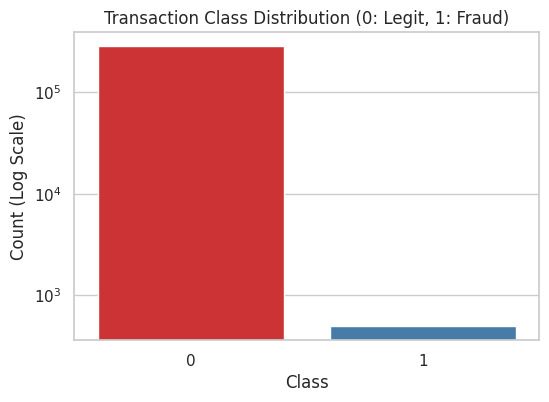

In [6]:
# Visualize the class imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='Set1')
plt.title('Transaction Class Distribution (0: Legit, 1: Fraud)')
plt.yscale('log') # Using log scale due to severe imbalance
plt.ylabel('Count (Log Scale)')
plt.show()

In [7]:
# Statistical summary of Time and Amount
df[['Time', 'Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


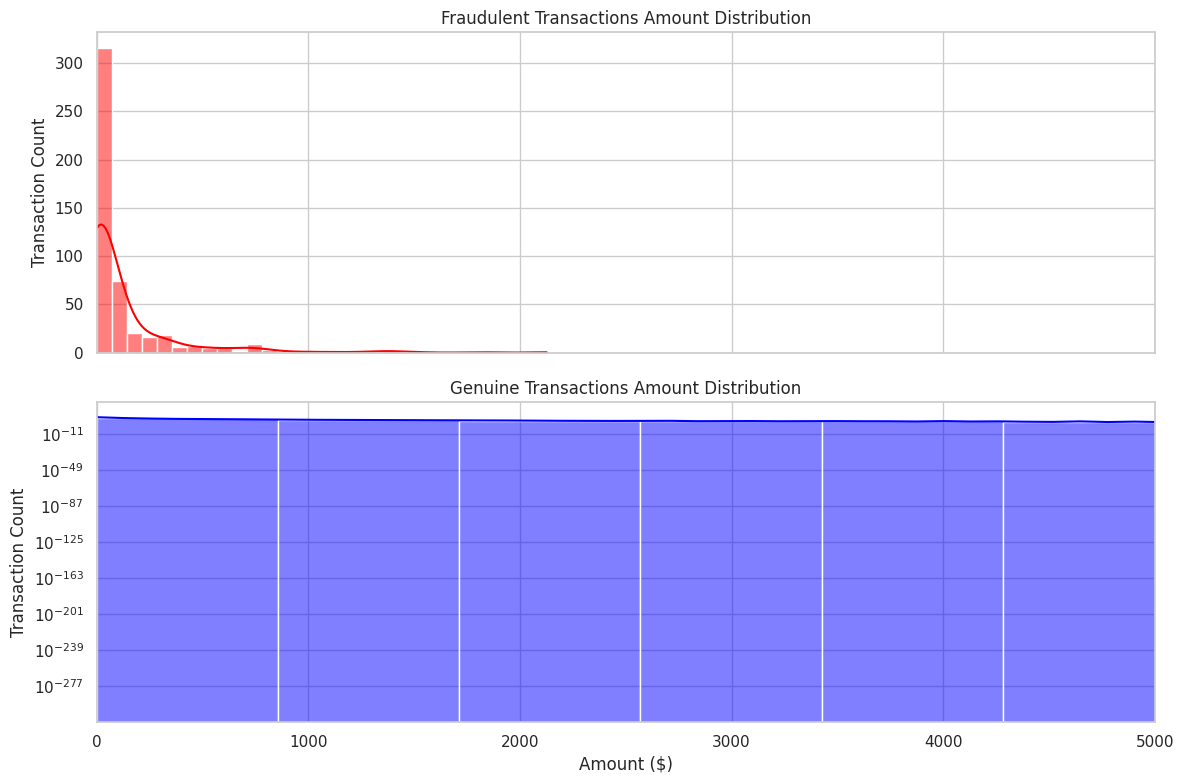

In [8]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

sns.histplot(df[df['Class'] == 1]['Amount'], bins=30, ax=ax1, color='red', kde=True)
ax1.set_title('Fraudulent Transactions Amount Distribution')
ax1.set_ylabel('Transaction Count')

sns.histplot(df[df['Class'] == 0]['Amount'], bins=30, ax=ax2, color='blue', kde=True)
ax2.set_title('Genuine Transactions Amount Distribution')
ax2.set_xlabel('Amount ($)')
ax2.set_ylabel('Transaction Count')

plt.xlim((0, 5000)) # Limiting x-axis to see the bulk of data clearly
plt.yscale('log')
plt.tight_layout()
plt.show()

In [9]:
missing_values = df.isnull().sum().sum()
print(f"Total Missing Values in Dataset: {missing_values}")

Total Missing Values in Dataset: 0


In [10]:
# Identify duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

# Remove duplicates
df.drop_duplicates(inplace=True)
print(f"Dataset shape after removing duplicates: {df.shape}")

Number of duplicate rows found: 1081
Dataset shape after removing duplicates: (283726, 31)


In [13]:
# -------------------------------------------------------------
# PHASE 1: Class Imbalance Analysis
# -------------------------------------------------------------
print("--- Class Distribution ---")
class_counts = df['Class'].value_counts()
class_percentages = df['Class'].value_counts(normalize=True) * 100

print(f"Legitimate Transactions (Class 0): {class_counts[0]:,} ({class_percentages[0]:.3f}%)")
print(f"Fraudulent Transactions (Class 1): {class_counts[1]:,} ({class_percentages[1]:.3f}%)")

# -------------------------------------------------------------
# PHASE 2: Feature Engineering (Robust Scaling for Heavy Tails)
# -------------------------------------------------------------
print("\n--- Engineering Features ---")

# We use RobustScaler for 'Amount' because financial transactions have massive outliers 
# that would distort a standard mean/variance scale.
robust_scaler = RobustScaler()
df['scaled_amount'] = robust_scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# For 'Time', standard scaling is sufficient to keep variances tight for XGBoost
standard_scaler = StandardScaler()
df['scaled_time'] = standard_scaler.fit_transform(df['Time'].values.reshape(-1, 1))

# Drop original unscaled features to prevent data duplication issues
df_cleaned = df.drop(['Time', 'Amount'], axis=1)

# Reorder columns to keep 'Class' cleanly at the very end
cols = [col for col in df_cleaned.columns if col != 'Class'] + ['Class']
df_cleaned = df_cleaned[cols]

print(f"✅ Engineering Complete. Transformed shape: {df_cleaned.shape[0]:,} rows, {df_cleaned.shape[1]} columns.")
df_cleaned.head()

--- Class Distribution ---
Legitimate Transactions (Class 0): 284,315 (99.827%)
Fraudulent Transactions (Class 1): 492 (0.173%)

--- Engineering Features ---
✅ Engineering Complete. Transformed shape: 284,807 rows, 31 columns.


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,scaled_amount,scaled_time,Class
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,1.783274,-1.996583,0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.269825,-1.996583,0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,4.983721,-1.996562,0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,1.418291,-1.996562,0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.670579,-1.996541,0
